In [ ]:
!uv pip install \
lightgbm==4.3.0 \
xgboost==2.0.3 \
optuna \
optuna-integration \
shap \
river \
wandb \
kaggle \
plotly \
seaborn \
imbalanced-learn \
category-encoders category_encoders==2.6.3 transformers==4.41.2 sentence-transformers==2.7.0 numpy==1.26.4 scipy==1.11.4 scikit-learn==1.4.2

In [1]:
import transformers, sentence_transformers
print(transformers.__version__)
print(sentence_transformers.__version__)

4.41.2
2.7.0


In [ ]:
import os, gc, warnings, json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import plotly.express as px
import plotly.graph_objects as go
warnings.filterwarnings("ignore")

# Core ML
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
import category_encoders as ce
import optuna
from optuna.integration import LightGBMPruningCallback
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap
from river import stream, drift, linear_model, preprocessing as river_preprocessing, metrics as river_metrics, ensemble as river_ensemble
import wandb

from sentence_transformers import SentenceTransformer
import transformers


wandb.login(key=os.environ.get("WANDB_API_KEY", "paste yours not mine :/"))


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: suvradeep (suvradeep-iit-guwahati-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:

from dataclasses import dataclass, field
from typing import List

@dataclass
class CFG:
    # Paths
    DATA_DIR: str = "/kaggle/input/competitions/home-credit-default-risk"
    OUTPUT_DIR: str = "/kaggle/working"
    MODEL_DIR: str = "/kaggle/working/models"
    
    # Experiment
    EXPERIMENT_NAME: str = "credit-invisibility"
    SEED: int = 42
    N_FOLDS: int = 5
    
    # Training
    LGBM_N_ITER: int = 2000
    XGB_N_ITER: int = 1500
    EARLY_STOPPING: int = 100
    OPTUNA_TRIALS: int = 80
    
    # NLP
    SBERT_MODEL: str = "all-MiniLM-L6-v2"   # lightweight, fast
    NLP_DIM_REDUCTION: int = 32              # PCA to 32 dims
    
    # Drift simulation
    DRIFT_FRACTION: float = 0.15
    DRIFT_INCOME_MULTIPLIER: float = 0.4
    
    # W&B
    WANDB_PROJECT: str = "credit-invisibility"
    WANDB_ENTITY: str = None  # set your username

cfg = CFG()
os.makedirs(cfg.MODEL_DIR, exist_ok=True)
np.random.seed(cfg.SEED)
print("✅ Config loaded:", cfg)

✅ Config loaded: CFG(DATA_DIR='/kaggle/input/competitions/home-credit-default-risk', OUTPUT_DIR='/kaggle/working', MODEL_DIR='/kaggle/working/models', EXPERIMENT_NAME='credit-invisibility', SEED=42, N_FOLDS=5, LGBM_N_ITER=2000, XGB_N_ITER=1500, EARLY_STOPPING=100, OPTUNA_TRIALS=80, SBERT_MODEL='all-MiniLM-L6-v2', NLP_DIM_REDUCTION=32, DRIFT_FRACTION=0.15, DRIFT_INCOME_MULTIPLIER=0.4, WANDB_PROJECT='credit-invisibility', WANDB_ENTITY=None)


In [4]:
def load_all_tables(data_dir: str) -> dict:
    tables = {}
    files = {
        "app_train":      "application_train.csv",
        "app_test":       "application_test.csv",
        "bureau":         "bureau.csv",
        "bureau_balance": "bureau_balance.csv",
        "prev_app":       "previous_application.csv",
        "pos_cash":       "POS_CASH_balance.csv",
        "installments":   "installments_payments.csv",
        "credit_card":    "credit_card_balance.csv",
    }
    for key, fname in files.items():
        path = os.path.join(data_dir, fname)
        if os.path.exists(path):
            tables[key] = pd.read_csv(path)
            print(f"  ✅ {key:20s} → {tables[key].shape}")
        else:
            print(f"    {key:20s} → NOT FOUND")
    return tables

print("📂 Loading all Home Credit tables...")
tables = load_all_tables(cfg.DATA_DIR)

# Quick snapshot
train = tables["app_train"]
test  = tables["app_test"]

print(f"\n Train shape: {train.shape}")
print(f" Test shape:  {test.shape}")
print(f"\n Target distribution:\n{train['TARGET'].value_counts(normalize=True).round(3)}")
print(f"\n  Class imbalance ratio: {train['TARGET'].value_counts()[0]/train['TARGET'].value_counts()[1]:.1f}:1")

📂 Loading all Home Credit tables...
  ✅ app_train            → (307511, 122)
  ✅ app_test             → (48744, 121)
  ✅ bureau               → (1716428, 17)
  ✅ bureau_balance       → (27299925, 3)
  ✅ prev_app             → (1670214, 37)
  ✅ pos_cash             → (10001358, 8)
  ✅ installments         → (13605401, 8)
  ✅ credit_card          → (3840312, 23)

 Train shape: (307511, 122)
 Test shape:  (48744, 121)

 Target distribution:
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64

  Class imbalance ratio: 11.4:1


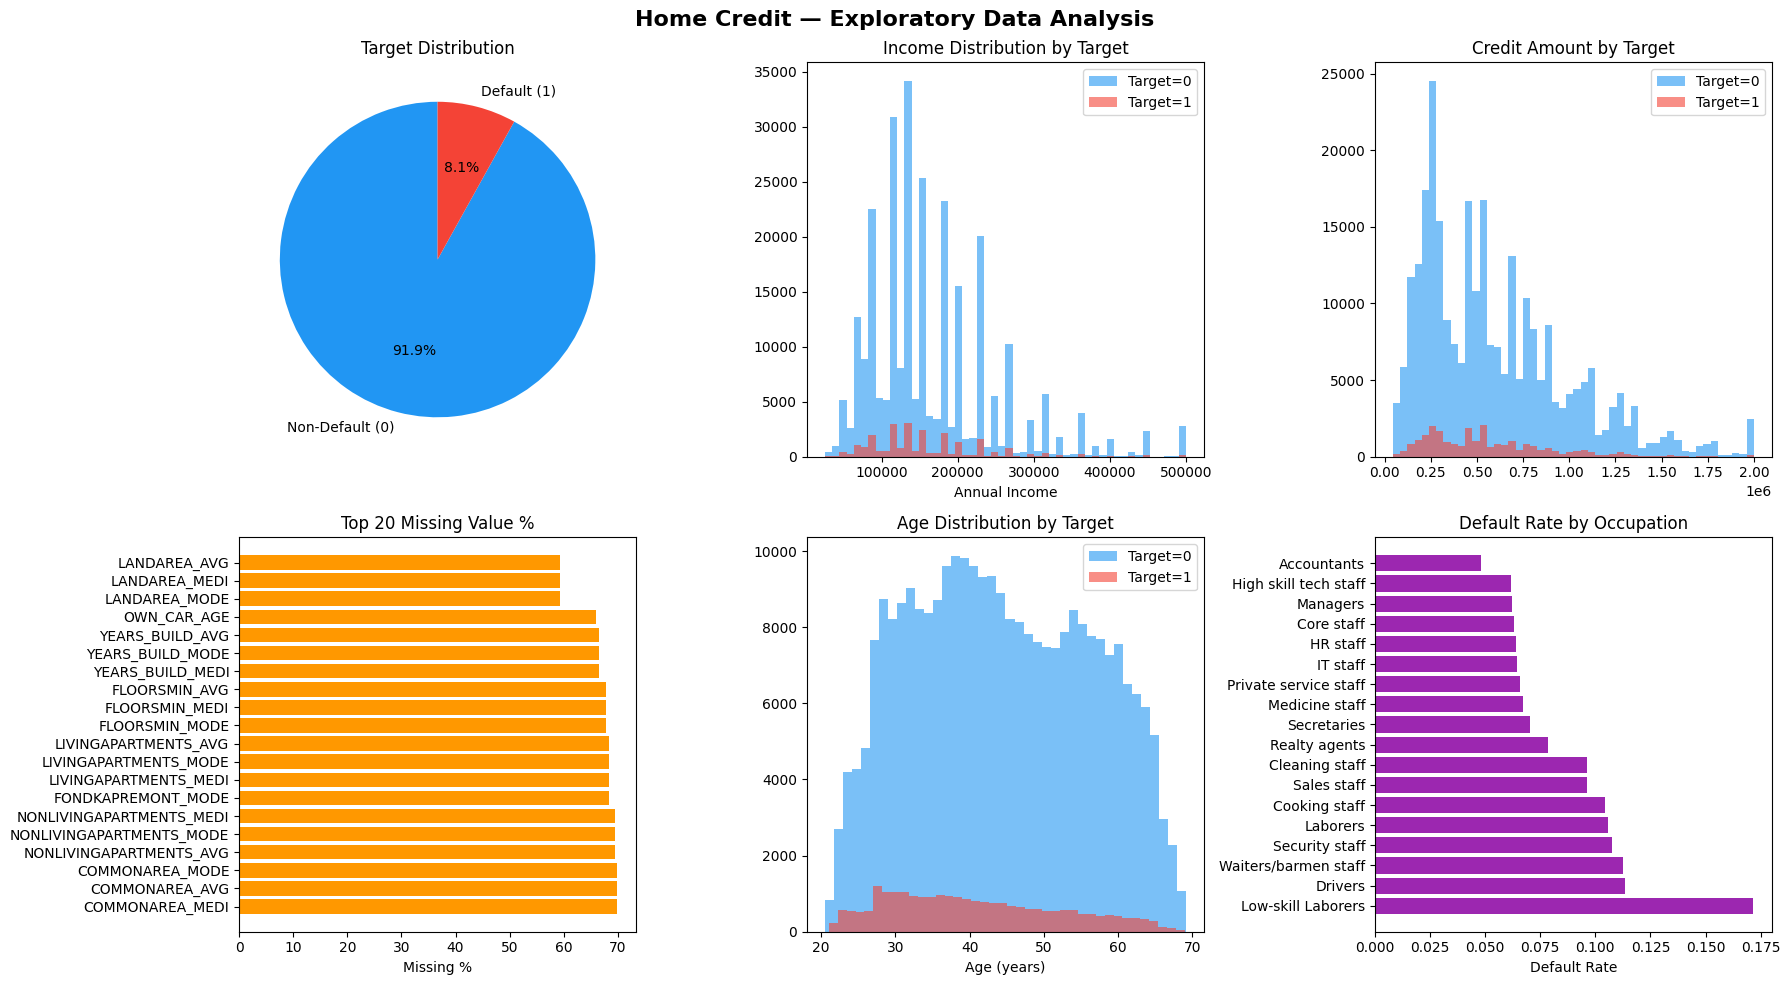

✅ EDA plots saved


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Home Credit — Exploratory Data Analysis", fontsize=16, fontweight="bold")

# 1. Target distribution
axes[0,0].pie(
    train["TARGET"].value_counts(),
    labels=["Non-Default (0)", "Default (1)"],
    autopct="%1.1f%%", colors=["#2196F3","#F44336"], startangle=90
)
axes[0,0].set_title("Target Distribution")

# 2. Income distribution by target
for t, color in zip([0, 1], ["#2196F3", "#F44336"]):
    subset = train[train["TARGET"] == t]["AMT_INCOME_TOTAL"].clip(0, 500000)
    axes[0,1].hist(subset, bins=50, alpha=0.6, label=f"Target={t}", color=color)
axes[0,1].set_title("Income Distribution by Target")
axes[0,1].legend()
axes[0,1].set_xlabel("Annual Income")

# 3. Credit amount by target
for t, color in zip([0, 1], ["#2196F3", "#F44336"]):
    subset = train[train["TARGET"] == t]["AMT_CREDIT"].clip(0, 2000000)
    axes[0,2].hist(subset, bins=50, alpha=0.6, label=f"Target={t}", color=color)
axes[0,2].set_title("Credit Amount by Target")
axes[0,2].legend()

# 4. Missing value heatmap (top 20)
missing = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False).head(20)
axes[1,0].barh(missing.index, missing.values, color="#FF9800")
axes[1,0].set_title("Top 20 Missing Value %")
axes[1,0].set_xlabel("Missing %")

# 5. Age distribution
age_years = train["DAYS_BIRTH"].abs() / 365
for t, color in zip([0, 1], ["#2196F3", "#F44336"]):
    subset = age_years[train["TARGET"] == t]
    axes[1,1].hist(subset, bins=40, alpha=0.6, label=f"Target={t}", color=color)
axes[1,1].set_title("Age Distribution by Target")
axes[1,1].set_xlabel("Age (years)")
axes[1,1].legend()

# 6. Occupation type default rate
occ_default = train.groupby("OCCUPATION_TYPE")["TARGET"].mean().sort_values(ascending=False)
axes[1,2].barh(occ_default.index, occ_default.values, color="#9C27B0")
axes[1,2].set_title("Default Rate by Occupation")
axes[1,2].set_xlabel("Default Rate")

plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ EDA plots saved")

In [6]:
def engineer_bureau_features(bureau: pd.DataFrame, bureau_balance: pd.DataFrame) -> pd.DataFrame:
    """Extract rich signals from external credit bureau data."""
    
    # Bureau balance — rolling DPD (days past due) features
    bb_agg = bureau_balance.groupby("SK_ID_BUREAU").agg(
        STATUS_WORST  = ("STATUS", lambda x: x.map({"C":0,"0":0,"1":1,"2":2,"3":3,"4":4,"5":5,"X":0}).max()),
        STATUS_MEAN   = ("STATUS", lambda x: x.map({"C":0,"0":0,"1":1,"2":2,"3":3,"4":4,"5":5,"X":0}).mean()),
        MONTHS_COUNT  = ("MONTHS_BALANCE", "count"),
    ).reset_index()
    
    bureau = bureau.merge(bb_agg, on="SK_ID_BUREAU", how="left")
    
    # Active vs closed credit
    bureau["CREDIT_ACTIVE_BINARY"] = (bureau["CREDIT_ACTIVE"] == "Active").astype(int)
    bureau["DAYS_CREDIT_ENDDATE"]  = bureau["DAYS_CREDIT_ENDDATE"].clip(-3000, 3000)
    bureau["DEBT_CREDIT_RATIO"]    = bureau["AMT_CREDIT_SUM_DEBT"] / (bureau["AMT_CREDIT_SUM"] + 1)
    bureau["CREDIT_UTIL_RATE"]     = bureau["AMT_CREDIT_SUM_OVERDUE"] / (bureau["AMT_CREDIT_SUM"] + 1)
    
    aggregations = {
        "DAYS_CREDIT":            ["mean","min","max","std"],
        "CREDIT_DAY_OVERDUE":     ["mean","max","sum"],
        "DAYS_CREDIT_ENDDATE":    ["mean","min","max"],
        "AMT_CREDIT_SUM":         ["mean","max","sum"],
        "AMT_CREDIT_SUM_DEBT":    ["mean","max","sum"],
        "AMT_CREDIT_SUM_OVERDUE": ["mean","max","sum"],
        "DEBT_CREDIT_RATIO":      ["mean","max"],
        "CREDIT_UTIL_RATE":       ["mean","max"],
        "CREDIT_ACTIVE_BINARY":   ["mean","sum"],
        "STATUS_WORST":           ["mean","max"],
        "STATUS_MEAN":            ["mean"],
        "MONTHS_COUNT":           ["mean","sum"],
        "CNT_CREDIT_PROLONG":     ["sum","mean"],
    }
    
    bureau_agg = bureau.groupby("SK_ID_CURR").agg(aggregations)
    bureau_agg.columns = ["BUREAU_" + "_".join(col).upper() for col in bureau_agg.columns]
    
    # Count of bureau records (signal for credit footprint)
    bureau_agg["BUREAU_COUNT"] = bureau.groupby("SK_ID_CURR").size()
    bureau_agg["BUREAU_ACTIVE_COUNT"] = bureau.groupby("SK_ID_CURR")["CREDIT_ACTIVE_BINARY"].sum()
    
    return bureau_agg.reset_index()

bureau_features = engineer_bureau_features(tables["bureau"], tables["bureau_balance"])
print(f"✅ Bureau features: {bureau_features.shape}")

✅ Bureau features: (305811, 35)


In [7]:
def engineer_prev_app_features(prev: pd.DataFrame) -> pd.DataFrame:
    prev["APP_CREDIT_RATIO"]       = prev["AMT_APPLICATION"] / (prev["AMT_CREDIT"] + 1)
    prev["DOWN_PAYMENT_RATIO"]     = prev["AMT_DOWN_PAYMENT"] / (prev["AMT_CREDIT"] + 1)
    prev["ANNUITY_CREDIT_RATIO"]   = prev["AMT_ANNUITY"] / (prev["AMT_CREDIT"] + 1)
    prev["APPROVED"]               = (prev["NAME_CONTRACT_STATUS"] == "Approved").astype(int)
    prev["REFUSED"]                = (prev["NAME_CONTRACT_STATUS"] == "Refused").astype(int)
    
    agg = prev.groupby("SK_ID_CURR").agg(
        PREV_COUNT                = ("SK_ID_PREV",            "count"),
        PREV_APPROVED_RATE        = ("APPROVED",              "mean"),
        PREV_REFUSED_RATE         = ("REFUSED",               "mean"),
        PREV_APP_CREDIT_RATIO_MEAN= ("APP_CREDIT_RATIO",      "mean"),
        PREV_ANNUITY_MEAN         = ("AMT_ANNUITY",           "mean"),
        PREV_CREDIT_MEAN          = ("AMT_CREDIT",            "mean"),
        PREV_DAYS_DECISION_MEAN   = ("DAYS_DECISION",         "mean"),
        PREV_DAYS_DECISION_MIN    = ("DAYS_DECISION",         "min"),
        PREV_GOODS_PRICE_MEAN     = ("AMT_GOODS_PRICE",       "mean"),
    ).reset_index()
    agg.columns = ["SK_ID_CURR"] + ["PREV_" + c if not c.startswith("PREV") else c for c in agg.columns[1:]]
    return agg

def engineer_installments_features(inst: pd.DataFrame) -> pd.DataFrame:
    inst["PAYMENT_DIFF"]     = inst["AMT_INSTALMENT"] - inst["AMT_PAYMENT"]
    inst["DAYS_ENTRY_DIFF"]  = inst["DAYS_INSTALMENT"] - inst["DAYS_ENTRY_PAYMENT"]
    inst["LATE_PAYMENT"]     = (inst["DAYS_ENTRY_DIFF"] > 0).astype(int)
    inst["SHORT_PAYMENT"]    = (inst["PAYMENT_DIFF"] > 0).astype(int)
    
    agg = inst.groupby("SK_ID_CURR").agg(
        INST_PAYMENT_DIFF_MEAN  = ("PAYMENT_DIFF",    "mean"),
        INST_PAYMENT_DIFF_MAX   = ("PAYMENT_DIFF",    "max"),
        INST_DAYS_ENTRY_DIFF_MEAN=("DAYS_ENTRY_DIFF", "mean"),
        INST_LATE_PAYMENT_RATE  = ("LATE_PAYMENT",    "mean"),
        INST_SHORT_PAYMENT_RATE = ("SHORT_PAYMENT",   "mean"),
        INST_COUNT              = ("SK_ID_PREV",      "count"),
    ).reset_index()
    return agg

def engineer_pos_cash_features(pos: pd.DataFrame) -> pd.DataFrame:
    pos["DPD_BINARY"] = (pos["SK_DPD"] > 0).astype(int)
    agg = pos.groupby("SK_ID_CURR").agg(
        POS_MONTHS_COUNT    = ("MONTHS_BALANCE",  "count"),
        POS_SK_DPD_MEAN     = ("SK_DPD",          "mean"),
        POS_SK_DPD_MAX      = ("SK_DPD",          "max"),
        POS_DPD_RATE        = ("DPD_BINARY",       "mean"),
        POS_CNT_INSTALMENT_MEAN=("CNT_INSTALMENT", "mean"),
    ).reset_index()
    return agg

def engineer_credit_card_features(cc: pd.DataFrame) -> pd.DataFrame:
    cc["UTIL_RATE"]   = cc["AMT_BALANCE"] / (cc["AMT_CREDIT_LIMIT_ACTUAL"] + 1)
    cc["DRAWING_RATE"]= cc["AMT_DRAWINGS_CURRENT"] / (cc["AMT_CREDIT_LIMIT_ACTUAL"] + 1)
    agg = cc.groupby("SK_ID_CURR").agg(
        CC_UTIL_RATE_MEAN   = ("UTIL_RATE",       "mean"),
        CC_UTIL_RATE_MAX    = ("UTIL_RATE",        "max"),
        CC_DRAWING_RATE_MEAN= ("DRAWING_RATE",     "mean"),
        CC_AMT_BALANCE_MEAN = ("AMT_BALANCE",      "mean"),
        CC_COUNT            = ("SK_ID_PREV",        "count"),
        CC_DPD_MEAN         = ("SK_DPD",           "mean"),
    ).reset_index()
    return agg

prev_features  = engineer_prev_app_features(tables["prev_app"])
inst_features  = engineer_installments_features(tables["installments"])
pos_features   = engineer_pos_cash_features(tables["pos_cash"])
cc_features    = engineer_credit_card_features(tables["credit_card"])

print(f"✅ Prev app features:   {prev_features.shape}")
print(f"✅ Installments features:{inst_features.shape}")
print(f"✅ POS Cash features:   {pos_features.shape}")
print(f"✅ Credit Card features:{cc_features.shape}")

✅ Prev app features:   (338857, 10)
✅ Installments features:(339587, 7)
✅ POS Cash features:   (337252, 6)
✅ Credit Card features:(103558, 7)


In [8]:
def engineer_app_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # Domain knowledge ratios
    df["CREDIT_INCOME_RATIO"]       = df["AMT_CREDIT"] / (df["AMT_INCOME_TOTAL"] + 1)
    df["ANNUITY_INCOME_RATIO"]      = df["AMT_ANNUITY"] / (df["AMT_INCOME_TOTAL"] + 1)
    df["CREDIT_TERM"]               = df["AMT_ANNUITY"] / (df["AMT_CREDIT"] + 1)
    df["GOODS_CREDIT_RATIO"]        = df["AMT_GOODS_PRICE"] / (df["AMT_CREDIT"] + 1)
    
    # Age and employment signals
    df["AGE_YEARS"]                 = df["DAYS_BIRTH"].abs() / 365.25
    df["EMPLOYMENT_YEARS"]          = df["DAYS_EMPLOYED"].apply(lambda x: abs(x)/365.25 if x < 0 else 0)
    df["EMPLOYED_RATIO"]            = df["EMPLOYMENT_YEARS"] / (df["AGE_YEARS"] + 1)
    df["CREDIT_TO_AGE"]             = df["AMT_CREDIT"] / (df["AGE_YEARS"] + 1)
    
    # Family / social signals
    df["INCOME_PER_PERSON"]         = df["AMT_INCOME_TOTAL"] / (df["CNT_FAM_MEMBERS"] + 1)
    df["CHILDREN_RATIO"]            = df["CNT_CHILDREN"] / (df["CNT_FAM_MEMBERS"] + 1)
    
    # External scores (most predictive in Home Credit baseline)
    df["EXT_SOURCE_MEAN"]           = df[["EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3"]].mean(axis=1)
    df["EXT_SOURCE_MIN"]            = df[["EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3"]].min(axis=1)
    df["EXT_SOURCE_PROD"]           = df["EXT_SOURCE_1"] * df["EXT_SOURCE_2"] * df["EXT_SOURCE_3"]
    df["EXT_SOURCE_STD"]            = df[["EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3"]].std(axis=1)
    df["EXT1_EXT2_INTERACTION"]     = df["EXT_SOURCE_1"] * df["EXT_SOURCE_2"]
    df["EXT2_EXT3_INTERACTION"]     = df["EXT_SOURCE_2"] * df["EXT_SOURCE_3"]
    df["EXT_CREDIT_RATIO"]          = df["EXT_SOURCE_MEAN"] * df["CREDIT_INCOME_RATIO"]
    
    # Document flags — count missing documents
    doc_cols = [c for c in df.columns if "FLAG_DOCUMENT" in c]
    df["DOCUMENT_COUNT"]            = df[doc_cols].sum(axis=1)
    
    # Enquiry signals (loan shopping behavior)
    enq_cols = [c for c in df.columns if "AMT_REQ_CREDIT_BUREAU" in c]
    df["TOTAL_ENQUIRIES"]           = df[enq_cols].sum(axis=1)
    df["RECENT_ENQUIRY_RATIO"]      = df.get("AMT_REQ_CREDIT_BUREAU_WEEK", pd.Series(0, index=df.index)) / (df["TOTAL_ENQUIRIES"] + 1)
    
    # Car & realty
    df["HAS_CAR_REALTY"]            = ((df["FLAG_OWN_CAR"] == "Y") & (df["FLAG_OWN_REALTY"] == "Y")).astype(int)
    
    # Days registration relative to application
    df["DAYS_REGISTRATION_RATIO"]   = df["DAYS_REGISTRATION"] / (df["DAYS_BIRTH"] + 1)
    
    # Label encode categoricals
    cat_cols = df.select_dtypes("object").columns.tolist()
    le = LabelEncoder()
    for col in cat_cols:
        df[col] = df[col].fillna("Unknown")
        df[col] = le.fit_transform(df[col].astype(str))
    
    return df

train_eng = engineer_app_features(train)
test_eng  = engineer_app_features(test)
print(f"✅ Engineered features: {train_eng.shape}")

✅ Engineered features: (307511, 144)


In [9]:
def generate_financial_descriptions(df: pd.DataFrame) -> list:
    """
    Synthesize a financial narrative per applicant from tabular data.
    This simulates what a financial literacy assessment text would contain.
    """
    descriptions = []
    for _, row in df.iterrows():
        age = abs(row.get("DAYS_BIRTH", -365*35)) / 365
        income = row.get("AMT_INCOME_TOTAL", 100000)
        credit = row.get("AMT_CREDIT", 200000)
        ext_score = row.get("EXT_SOURCE_MEAN", 0.5)
        emp_years = max(0, -row.get("DAYS_EMPLOYED", -5*365)) / 365
        
        # Map external score to financial literacy level
        if ext_score > 0.65:
            literacy = "demonstrates strong financial planning habits and consistently pays bills on time"
        elif ext_score > 0.45:
            literacy = "shows moderate financial awareness with occasional late payments"
        else:
            literacy = "has limited financial experience and irregular payment patterns"
        
        desc = (
            f"Applicant aged {age:.0f} years with annual income of {income:.0f} currency units. "
            f"Requesting credit of {credit:.0f} for personal needs. "
            f"Employed for {emp_years:.1f} years in current position. "
            f"Client {literacy}. "
            f"External credit assessment score: {ext_score:.2f}. "
            f"{'Owns property which serves as collateral.' if row.get('FLAG_OWN_REALTY', 0) else 'No property ownership.'} "
            f"{'Has dependents in household.' if row.get('CNT_CHILDREN', 0) > 0 else 'No children.'}"
        )
        descriptions.append(desc)
    return descriptions

print("🔤 Generating financial narratives...")
train_texts = generate_financial_descriptions(train_eng)
test_texts  = generate_financial_descriptions(test_eng)
print(f"  Sample: {train_texts[0][:120]}...")

# Embed with Sentence-BERT
print("\n🤖 Loading SBERT model...")
sbert = SentenceTransformer(cfg.SBERT_MODEL)

print("  Encoding train texts (batch)...")
train_embeddings = sbert.encode(
    train_texts, batch_size=512, show_progress_bar=True,
    normalize_embeddings=True, convert_to_numpy=True
)

print("  Encoding test texts (batch)...")
test_embeddings = sbert.encode(
    test_texts, batch_size=512, show_progress_bar=True,
    normalize_embeddings=True, convert_to_numpy=True
)

print(f"\n✅ Embeddings shape: {train_embeddings.shape}")

# Reduce dims with PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=cfg.NLP_DIM_REDUCTION, random_state=cfg.SEED)
train_emb_reduced = pca.fit_transform(train_embeddings)
test_emb_reduced  = pca.transform(test_embeddings)

print(f"✅ After PCA: {train_emb_reduced.shape} | Explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# Create DataFrame
emb_cols = [f"NLP_EMB_{i}" for i in range(cfg.NLP_DIM_REDUCTION)]
train_nlp_df = pd.DataFrame(train_emb_reduced, columns=emb_cols, index=train_eng.index)
test_nlp_df  = pd.DataFrame(test_emb_reduced,  columns=emb_cols, index=test_eng.index)

del sbert, train_embeddings, test_embeddings; gc.collect()
print("✅ NLP features ready")

🔤 Generating financial narratives...
  Sample: Applicant aged 26 years with annual income of 202500 currency units. Requesting credit of 406598 for personal needs. Emp...

🤖 Loading SBERT model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

  Encoding train texts (batch)...


Batches:   0%|          | 0/601 [00:00<?, ?it/s]

  Encoding test texts (batch)...


Batches:   0%|          | 0/96 [00:00<?, ?it/s]


✅ Embeddings shape: (307511, 384)
✅ After PCA: (307511, 32) | Explained variance: 0.904
✅ NLP features ready


In [10]:
def merge_all_features(app_df, bureau_feat, prev_feat, inst_feat, pos_feat, cc_feat, nlp_feat):
    df = app_df.copy()
    df = df.merge(bureau_feat, on="SK_ID_CURR", how="left")
    df = df.merge(prev_feat,   on="SK_ID_CURR", how="left")
    df = df.merge(inst_feat,   on="SK_ID_CURR", how="left")
    df = df.merge(pos_feat,    on="SK_ID_CURR", how="left")
    df = df.merge(cc_feat,     on="SK_ID_CURR", how="left")
    
    # NLP features (index-aligned)
    nlp_feat_reset = nlp_feat.reset_index(drop=True)
    df = df.reset_index(drop=True)
    df = pd.concat([df, nlp_feat_reset], axis=1)
    
    return df

print("🔗 Merging all feature tables...")
train_full = merge_all_features(train_eng, bureau_features, prev_features, inst_features, pos_features, cc_features, train_nlp_df)
test_full  = merge_all_features(test_eng,  bureau_features, prev_features, inst_features, pos_features, cc_features, test_nlp_df)

print(f"✅ Final train shape: {train_full.shape}")
print(f"✅ Final test shape:  {test_full.shape}")

# Separate target + features
TARGET     = "TARGET"
DROP_COLS  = ["TARGET", "SK_ID_CURR"]
FEATURE_COLS = [c for c in train_full.columns if c not in DROP_COLS]

X = train_full[FEATURE_COLS]
y = train_full[TARGET]
X_test_final = test_full[FEATURE_COLS]

print(f"\n✅ X: {X.shape} | y: {y.shape}")
print(f"   NLP features: {sum(1 for c in FEATURE_COLS if 'NLP' in c)} | Tabular: {sum(1 for c in FEATURE_COLS if 'NLP' not in c)}")

🔗 Merging all feature tables...
✅ Final train shape: (307511, 236)
✅ Final test shape:  (48744, 235)

✅ X: (307511, 234) | y: (307511,)
   NLP features: 32 | Tabular: 202


In [11]:
def run_lgbm_baseline(X, y, X_test, cfg, params=None):
    """5-fold CV LightGBM with W&B logging."""
    
    run = wandb.init(
        project=cfg.WANDB_PROJECT,
        name="lgbm-baseline",
        config=params or {},
        tags=["baseline", "lgbm"]
    )
    
    default_params = {
        "objective":      "binary",
        "metric":         "auc",
        "boosting_type":  "gbdt",
        "num_leaves":     127,
        "learning_rate":  0.05,
        "feature_fraction": 0.85,
        "bagging_fraction": 0.85,
        "bagging_freq":   5,
        "min_child_samples": 20,
        "reg_alpha":      0.1,
        "reg_lambda":     0.1,
        "n_jobs":         -1,
        "seed":           cfg.SEED,
        "verbose":        -1,
    }
    if params:
        default_params.update(params)
    
    skf = StratifiedKFold(n_splits=cfg.N_FOLDS, shuffle=True, random_state=cfg.SEED)
    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    fold_scores = []
    models = []
    
    for fold, (trn_idx, val_idx) in enumerate(skf.split(X, y)):
        X_trn, X_val = X.iloc[trn_idx], X.iloc[val_idx]
        y_trn, y_val = y.iloc[trn_idx], y.iloc[val_idx]
        y_trn = y_trn.astype(np.float32)
        y_val = y_val.astype(np.float32)
        
        #dtrain = lgb.Dataset(X_trn, label=y_trn)
        #dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)
        dtrain = lgb.Dataset(X_trn, label=np.asarray(y_trn, dtype=np.float32))
        dval   = lgb.Dataset(X_val, label=np.asarray(y_val, dtype=np.float32), reference=dtrain)
        
        callbacks = [
            lgb.early_stopping(cfg.EARLY_STOPPING, verbose=False),
            lgb.log_evaluation(200),
        ]
        
        model = lgb.train(
            default_params,
            dtrain,
            num_boost_round=cfg.LGBM_N_ITER,
            valid_sets=[dval],
            callbacks=callbacks,
        )
        
        oof_preds[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
        test_preds += model.predict(X_test, num_iteration=model.best_iteration) / cfg.N_FOLDS
        
        score = roc_auc_score(y_val, oof_preds[val_idx])
        fold_scores.append(score)
        models.append(model)
        
        # W&B logging per fold
        wandb.log({f"fold_{fold+1}_auc": score, "fold": fold+1})
        print(f"  Fold {fold+1} | AUC: {score:.5f} | Best iter: {model.best_iteration}")
    
    oof_auc = roc_auc_score(y, oof_preds)
    print(f"\n🏆 OOF AUC: {oof_auc:.5f} ± {np.std(fold_scores):.5f}")
    
    # Log final metrics to W&B
    wandb.log({
        "oof_auc":      oof_auc,
        "fold_std":     np.std(fold_scores),
        "n_features":   X.shape[1],
        "n_train":      len(X),
    })
    
    # Feature importance
    fi = pd.DataFrame({
        "feature":    X.columns,
        "importance": np.mean([m.feature_importance("gain") for m in models], axis=0)
    }).sort_values("importance", ascending=False)
    
    # Log top-20 feature importance table
    wandb.log({"feature_importance": wandb.Table(dataframe=fi.head(20))})
    
    run.finish()
    return models, oof_preds, test_preds, oof_auc, fi

print("🚀 Running LightGBM Baseline...")
lgbm_models, lgbm_oof, lgbm_test, lgbm_auc, feat_imp = run_lgbm_baseline(X, y, X_test_final, cfg)

🚀 Running LightGBM Baseline...


[200]	valid_0's auc: 0.775678
  Fold 1 | AUC: 0.77593 | Best iter: 169
[200]	valid_0's auc: 0.784365
  Fold 2 | AUC: 0.78506 | Best iter: 266
[200]	valid_0's auc: 0.778904
  Fold 3 | AUC: 0.77896 | Best iter: 206
[200]	valid_0's auc: 0.784897
  Fold 4 | AUC: 0.78566 | Best iter: 297
[200]	valid_0's auc: 0.773547
  Fold 5 | AUC: 0.77408 | Best iter: 227

🏆 OOF AUC: 0.77992 ± 0.00470


fold,▁▃▅▆█
fold_1_auc,▁
fold_2_auc,▁
fold_3_auc,▁
fold_4_auc,▁
fold_5_auc,▁
fold_std,▁
n_features,▁
n_train,▁
oof_auc,▁
fold,5


In [12]:
def objective_lgbm(trial, X, y, cfg):
    params = {
        "objective": "binary",
        "metric": "auc",
        "verbosity": -1,
    
        # 🔥 GPU SETTINGS
        "device": "gpu",
        "gpu_platform_id": 0,
        "gpu_device_id": 0,
    
        # ⚡ Important for GPU stability
        "max_bin": 255,
        "gpu_use_dp": False,
    
        # Your search space
        "boosting_type": trial.suggest_categorical("boosting_type", ["gbdt", "dart"]),
        "num_leaves": trial.suggest_int("num_leaves", 31, 128),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "min_gain_to_split": trial.suggest_float("min_gain_to_split", 0.0, 0.5),
    
        "n_jobs": -1,
        "seed": cfg.SEED,
    }
    
    params["force_col_wise"] = True
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=cfg.SEED)
    scores = []
    
    for trn_idx, val_idx in skf.split(X, y):
        X_trn, X_val = X.iloc[trn_idx], X.iloc[val_idx]
        y_trn, y_val = y.iloc[trn_idx], y.iloc[val_idx]


        y_trn_np = np.asarray(y_trn, dtype=np.float32)
        y_val_np = np.asarray(y_val, dtype=np.float32)
        
        dtrain = lgb.Dataset(X_trn, label=y_trn_np)
        dval   = lgb.Dataset(X_val, label=y_val_np, reference=dtrain)


        
        #dtrain = lgb.Dataset(X_trn, label=y_trn)
        #dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)
        
        pruning_cb = LightGBMPruningCallback(trial, "auc")
        
        model = lgb.train(
            params, dtrain,
            num_boost_round=1000,
            valid_sets=[dval],
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(-1),
                pruning_cb,
            ]
        )
        preds = model.predict(X_val, num_iteration=model.best_iteration)
        scores.append(roc_auc_score(y_val, preds))
    
    return np.mean(scores)

print("🔍 Running Optuna HPO for LightGBM...")
print(f"   Trials: {cfg.OPTUNA_TRIALS}")

sampler  = optuna.samplers.TPESampler(seed=cfg.SEED)
pruner   = optuna.pruners.MedianPruner(n_warmup_steps=10)
study_lgbm = optuna.create_study(
    direction="maximize", sampler=sampler, pruner=pruner,
    study_name="lgbm-credit-hpo"
)

study_lgbm.optimize(
    lambda trial: objective_lgbm(trial, X, y, cfg),
    n_trials=cfg.OPTUNA_TRIALS,
    show_progress_bar=True,
    n_jobs=1,
)

best_lgbm_params = study_lgbm.best_params
best_lgbm_params.update({"objective":"binary","metric":"auc","verbosity":-1,"n_jobs":-1,"seed":cfg.SEED})

print(f"\n🏆 Best LightGBM AUC: {study_lgbm.best_value:.5f}")
print(f"   Best params: {json.dumps(best_lgbm_params, indent=2)}")



🔍 Running Optuna HPO for LightGBM...
   Trials: 80


  0%|          | 0/80 [00:00<?, ?it/s]

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.



🏆 Best LightGBM AUC: 0.78515
   Best params: {
  "boosting_type": "gbdt",
  "num_leaves": 112,
  "learning_rate": 0.02273805573563183,
  "feature_fraction": 0.7123738038749523,
  "bagging_fraction": 0.8170784332632994,
  "bagging_freq": 1,
  "min_child_samples": 82,
  "reg_alpha": 0.0002359137306347715,
  "reg_lambda": 8.598737339212267,
  "max_depth": 9,
  "min_gain_to_split": 0.0993578407670862,
  "objective": "binary",
  "metric": "auc",
  "verbosity": -1,
  "n_jobs": -1,
  "seed": 42
}


In [14]:
def objective_xgb(trial, X, y, cfg):
    params = {
        "objective":          "binary:logistic",
        "tree_method": "hist",
        "device": "cuda",          # ✅ enables GPU
        "max_bin": 256,            # ⚡ important for GPU speed
        "eval_metric":        "auc",
        "tree_method":        "hist",
        "use_label_encoder":  False,
        "learning_rate":      trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth":          trial.suggest_int("max_depth", 4, 10),
        "min_child_weight":   trial.suggest_int("min_child_weight", 1, 20),
        "subsample":          trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma":              trial.suggest_float("gamma", 0.0, 2.0),
        "reg_alpha":          trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda":         trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "scale_pos_weight":   trial.suggest_float("scale_pos_weight", 1.0, 10.0),
        "seed":               cfg.SEED,
        "n_jobs":             -1,
    }
    
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=cfg.SEED)
    scores = []
    
    for trn_idx, val_idx in skf.split(X, y):
        X_trn, X_val = X.iloc[trn_idx], X.iloc[val_idx]
        y_trn, y_val = y.iloc[trn_idx], y.iloc[val_idx]
        
        dtrain = xgb.DMatrix(X_trn, label=np.asarray(y_trn, dtype=np.float32))
        dval   = xgb.DMatrix(X_val, label=np.asarray(y_val, dtype=np.float32))

        
        model = xgb.train(
            params, dtrain,
            num_boost_round=1000,
            evals=[(dval, "val")],
            early_stopping_rounds=50,
            verbose_eval=False,
        )
        preds = model.predict(dval)
        scores.append(roc_auc_score(y_val, preds))
    
    return np.mean(scores)

print("🔍 Running Optuna HPO for XGBoost...")
study_xgb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=cfg.SEED),
    study_name="xgb-credit-hpo"
)
study_xgb.optimize(
    lambda trial: objective_xgb(trial, X, y, cfg),
    n_trials=cfg.OPTUNA_TRIALS,
    show_progress_bar=True,
)

best_xgb_params = study_xgb.best_params
best_xgb_params.update({"objective":"binary:logistic","eval_metric":"auc","tree_method":"hist","seed":cfg.SEED,"n_jobs":-1})

print(f"\n🏆 Best XGBoost AUC: {study_xgb.best_value:.5f}")

🔍 Running Optuna HPO for XGBoost...


  0%|          | 0/80 [00:00<?, ?it/s]


🏆 Best XGBoost AUC: 0.78596


In [15]:
def train_full_ensemble(X, y, X_test, lgbm_params, xgb_params, cfg):

    lgbm_params.update({
        "device": "gpu",
        "max_bin": 255,
        "gpu_use_dp": False,
        "force_col_wise": True
    })

    xgb_params.update({
        "device": "cuda",
        "tree_method": "hist",
        "max_bin": 256
    })

    run = wandb.init(
        project=cfg.WANDB_PROJECT,
        name="ensemble-lgbm-xgb",
        config={"lgbm": lgbm_params, "xgb": xgb_params, "n_folds": cfg.N_FOLDS},
        tags=["ensemble", "final"]
    )

    skf = StratifiedKFold(n_splits=cfg.N_FOLDS, shuffle=True, random_state=cfg.SEED)

    oof_lgbm  = np.zeros(len(X))
    oof_xgb   = np.zeros(len(X))
    test_lgbm = np.zeros(len(X_test))
    test_xgb  = np.zeros(len(X_test))

    lgbm_models_list = []
    xgb_models_list  = []

    for fold, (trn_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"\n🚀 Fold {fold+1}")

        X_trn, X_val = X.iloc[trn_idx], X.iloc[val_idx]
        y_trn, y_val = y.iloc[trn_idx], y.iloc[val_idx]

        y_trn_np = np.asarray(y_trn, dtype=np.float32)
        y_val_np = np.asarray(y_val, dtype=np.float32)

        dl_trn = lgb.Dataset(X_trn, label=y_trn_np)
        dl_val = lgb.Dataset(X_val, label=y_val_np, reference=dl_trn)

        lgb_model = lgb.train(
            lgbm_params,
            dl_trn,
            num_boost_round=cfg.LGBM_N_ITER,
            valid_sets=[dl_val],
            callbacks=[
                lgb.early_stopping(cfg.EARLY_STOPPING, verbose=False),
                lgb.log_evaluation(100),
            ]
        )

        lgb_val_pred = lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration)
        oof_lgbm[val_idx] = lgb_val_pred
        test_lgbm += lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration) / cfg.N_FOLDS
        lgbm_models_list.append(lgb_model)

        dx_trn = xgb.DMatrix(X_trn, label=y_trn_np)
        dx_val = xgb.DMatrix(X_val, label=y_val_np)
        dx_tst = xgb.DMatrix(X_test)

        xgb_model = xgb.train(
            xgb_params,
            dx_trn,
            num_boost_round=cfg.XGB_N_ITER,
            evals=[(dx_val, "val")],
            early_stopping_rounds=cfg.EARLY_STOPPING,
            verbose_eval=False,
        )

        xgb_val_pred = xgb_model.predict(dx_val)
        oof_xgb[val_idx] = xgb_val_pred
        test_xgb += xgb_model.predict(dx_tst) / cfg.N_FOLDS
        xgb_models_list.append(xgb_model)

        # Fold metrics
        auc_l = roc_auc_score(y_val, lgb_val_pred)
        auc_x = roc_auc_score(y_val, xgb_val_pred)

        print(f"  LGBM: {auc_l:.5f} | XGB: {auc_x:.5f}")


    print("\n🔍 Optimizing blend weights...")

    best_auc = 0
    best_w = 0.5

    for w in np.arange(0.0, 1.01, 0.01):
        blend = w * oof_lgbm + (1 - w) * oof_xgb
        auc = roc_auc_score(y, blend)

        if auc > best_auc:
            best_auc = auc
            best_w = w

    print(f"✅ Best weight → LGBM: {best_w:.2f}, XGB: {1-best_w:.2f}")
    print(f"🏆 Best OOF AUC: {best_auc:.5f}")

    oof_blend  = best_w * oof_lgbm + (1 - best_w) * oof_xgb
    test_blend = best_w * test_lgbm + (1 - best_w) * test_xgb

    wandb.log({
        "final_oof_auc": best_auc,
        "lgbm_weight": best_w,
        "xgb_weight": 1 - best_w
    })

    run.finish()

    return lgbm_models_list, xgb_models_list, oof_lgbm, oof_xgb, oof_blend, test_blend


lgbm_models_final, xgb_models_final, oof_lgbm, oof_xgb, oof_blend, test_blend = train_full_ensemble(
    X, y, X_test_final, best_lgbm_params, best_xgb_params, cfg
)


🚀 Fold 1
[100]	valid_0's auc: 0.765307
[200]	valid_0's auc: 0.774084
[300]	valid_0's auc: 0.777392
[400]	valid_0's auc: 0.77907
[500]	valid_0's auc: 0.780086
[600]	valid_0's auc: 0.780793
[700]	valid_0's auc: 0.781234
[800]	valid_0's auc: 0.781458
[900]	valid_0's auc: 0.781597
  LGBM: 0.78174 | XGB: 0.78181

🚀 Fold 2
[100]	valid_0's auc: 0.773239
[200]	valid_0's auc: 0.783192
[300]	valid_0's auc: 0.786755
[400]	valid_0's auc: 0.788592
[500]	valid_0's auc: 0.78945
[600]	valid_0's auc: 0.789662
[700]	valid_0's auc: 0.789836
[800]	valid_0's auc: 0.789936
  LGBM: 0.79000 | XGB: 0.79209

🚀 Fold 3
[100]	valid_0's auc: 0.76562
[200]	valid_0's auc: 0.774939
[300]	valid_0's auc: 0.779674
[400]	valid_0's auc: 0.7817
[500]	valid_0's auc: 0.782736
[600]	valid_0's auc: 0.78322
[700]	valid_0's auc: 0.783531
[800]	valid_0's auc: 0.783716
[900]	valid_0's auc: 0.78377
  LGBM: 0.78383 | XGB: 0.78411

🚀 Fold 4
[100]	valid_0's auc: 0.773374
[200]	valid_0's auc: 0.782137
[300]	valid_0's auc: 0.786103
[400

final_oof_auc,▁
lgbm_weight,▁
xgb_weight,▁
final_oof_auc,0.78731
lgbm_weight,0.49
xgb_weight,0.51


🔍 Computing SHAP values (TreeExplainer)...


2026-03-31 09:58:29.751318: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774951109.967057     177 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774951110.036118     177 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774951110.580200     177 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774951110.580228     177 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774951110.580231     177 computation_placer.cc:177] computation placer alr

✅ SHAP values shape: (2000, 234)


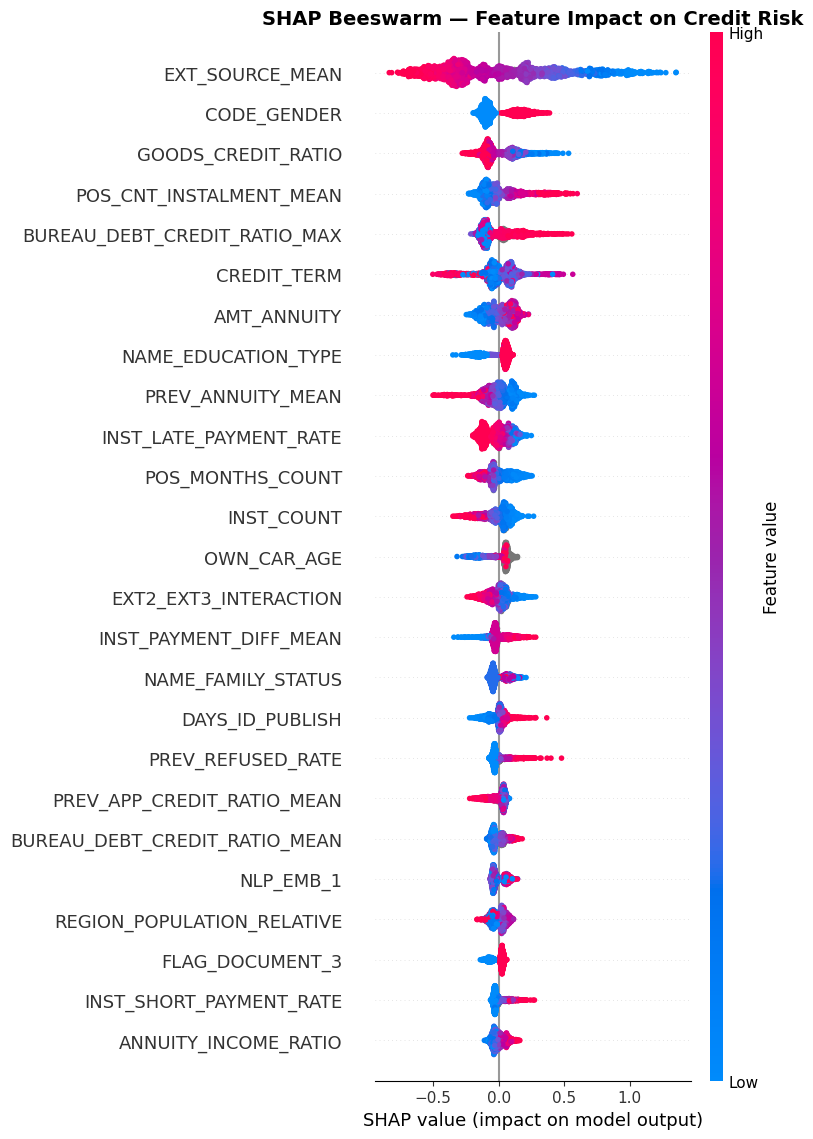

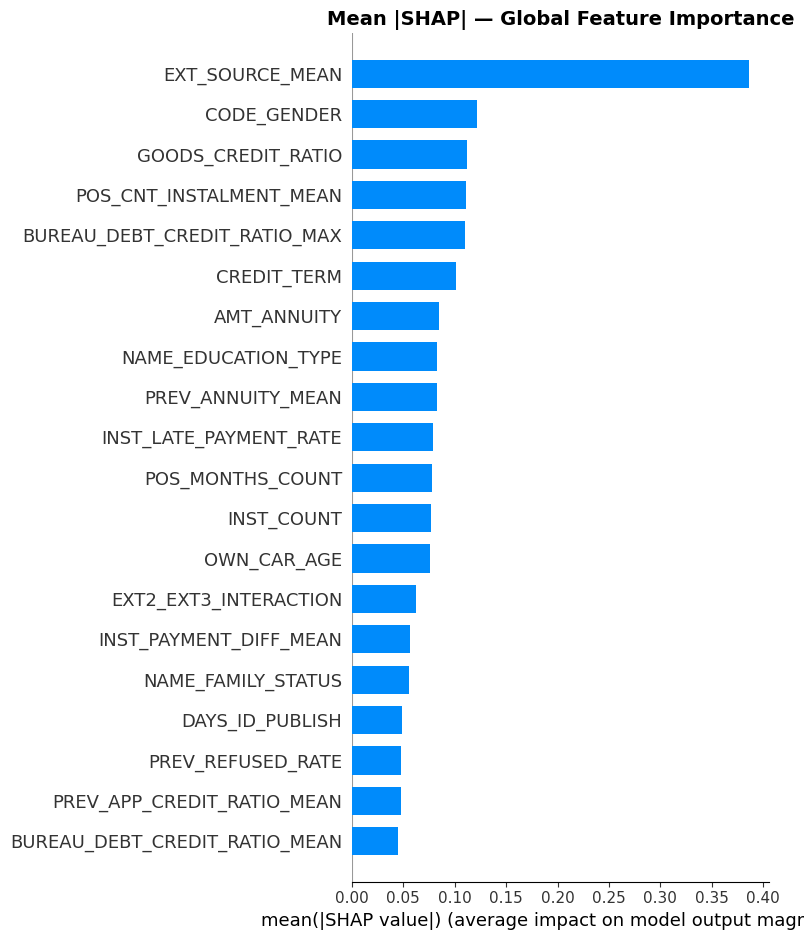

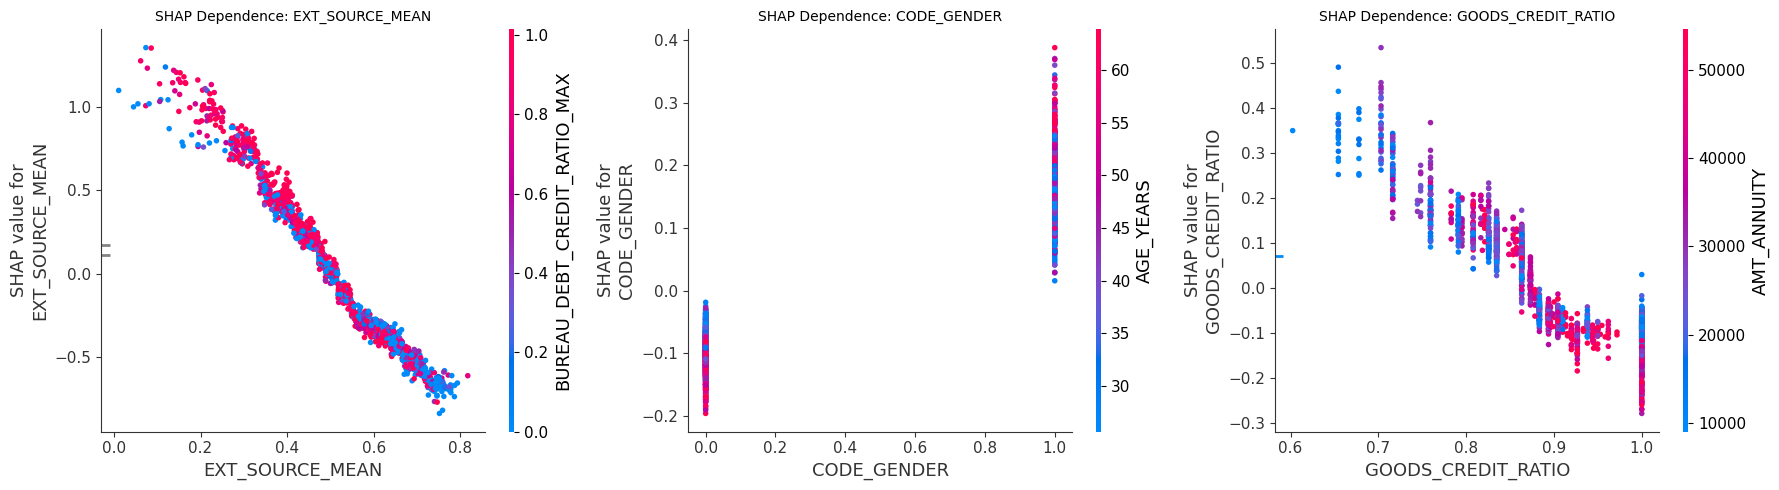

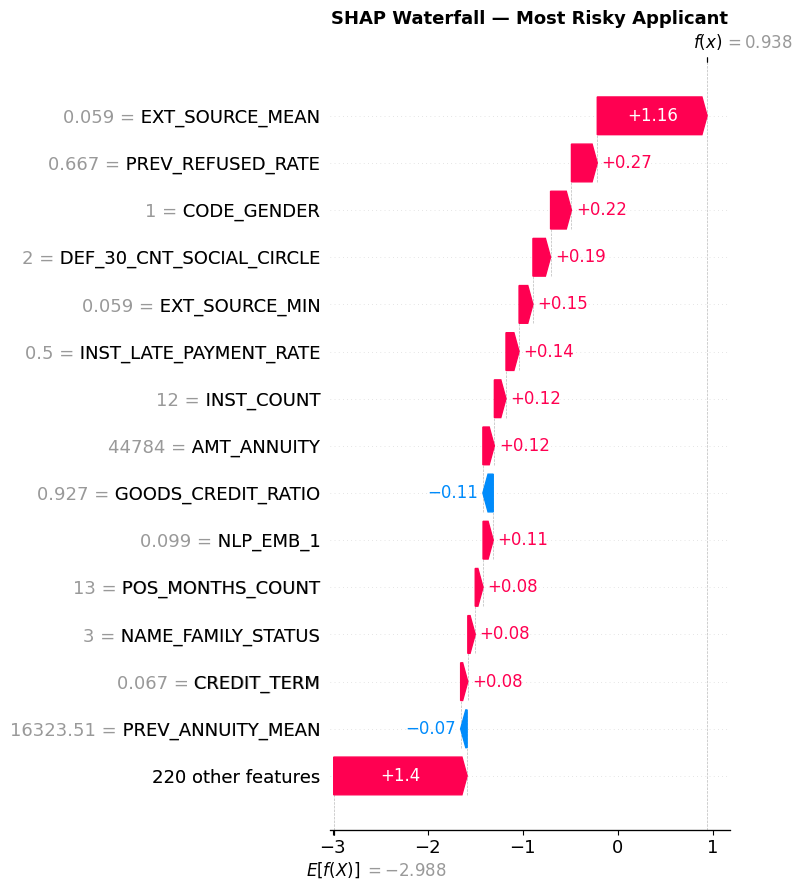

✅ All SHAP plots saved


In [16]:
print("🔍 Computing SHAP values (TreeExplainer)...")

# Use the first fold's LightGBM model for SHAP analysis
explainer = shap.TreeExplainer(lgbm_models_final[0])

# Sample 2000 rows for speed
sample_idx = np.random.choice(len(X), min(2000, len(X)), replace=False)
X_sample   = X.iloc[sample_idx]
shap_vals  = explainer.shap_values(X_sample)

# For binary classification, lgbm returns list [neg_class, pos_class]
if isinstance(shap_vals, list):
    shap_vals = shap_vals[1]

print(f"✅ SHAP values shape: {shap_vals.shape}")

# ── 1. Beeswarm / Summary Plot ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
shap.summary_plot(shap_vals, X_sample, plot_type="dot", max_display=25, show=False)
plt.title("SHAP Beeswarm — Feature Impact on Credit Risk", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 2. Bar Plot (mean |SHAP|) ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_vals, X_sample, plot_type="bar", max_display=20, show=False)
plt.title("Mean |SHAP| — Global Feature Importance", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 3. Dependence Plots for top 3 features ──────────────────────────
top3_features = pd.DataFrame({
    "feature": X.columns,
    "mean_shap": np.abs(shap_vals).mean(0)
}).nlargest(3, "mean_shap")["feature"].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, top3_features):
    feat_idx = list(X.columns).index(feat)
    shap.dependence_plot(feat_idx, shap_vals, X_sample, ax=ax, show=False)
    ax.set_title(f"SHAP Dependence: {feat}", fontsize=10)
plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/shap_dependence.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 4. Waterfall for single applicant (most risky) ───────────────────
most_risky_idx = np.argmax(oof_blend[sample_idx])
expl_obj = shap.Explanation(
    values     = shap_vals[most_risky_idx],
    base_values= explainer.expected_value if not isinstance(explainer.expected_value, list) else explainer.expected_value[1],
    data       = X_sample.iloc[most_risky_idx].values,
    feature_names=X_sample.columns.tolist()
)
plt.figure(figsize=(14, 8))
shap.plots.waterfall(expl_obj, max_display=15, show=False)
plt.title("SHAP Waterfall — Most Risky Applicant", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ All SHAP plots saved")

📉 Simulating Concept Drift...


  Baseline AUC (no drift): 0.78798
  Baseline (No Drift)                      | AUC: 0.87739 | Drop: -0.08941
  Mild Income Shock (-30%)                 | AUC: 0.80334 | Drop: -0.01536
  Severe Income Shock (-60%)               | AUC: 0.73259 | Drop: +0.05540
  Mass Job Loss (20%)                      | AUC: 0.68183 | Drop: +0.10615
  Full Economic Shock                      | AUC: 0.64217 | Drop: +0.14581


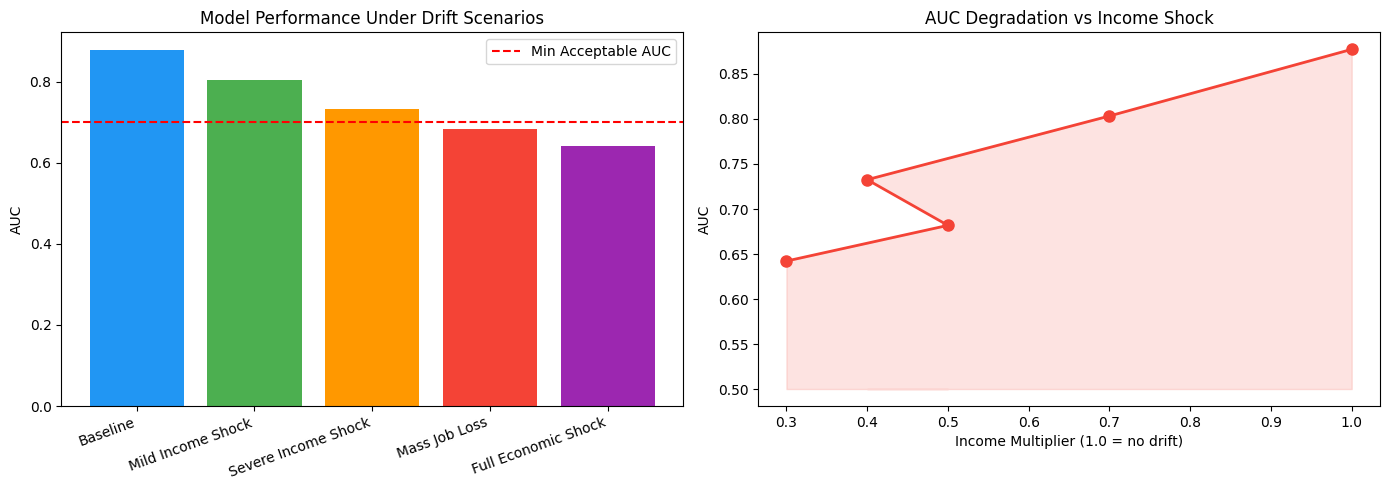

drifted_auc,█▆▄▂▁
drifted_auc,0.64217
scenario,Full Economic Shock


✅ Drift simulation complete


In [18]:
print("📉 Simulating Concept Drift...")

run = wandb.init(
    project=cfg.WANDB_PROJECT,
    name="concept-drift-simulation",
    tags=["drift", "simulation"]
)

# ── Get validation split (index-aligned with X, y) ────────────────────────────
skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=cfg.SEED)
trn_idx, val_idx = list(skf.split(X, y))[0]

y_val_drift = y.iloc[val_idx].values

# Baseline AUC using ensemble OOF preds (already computed over full X)
base_preds = oof_blend[val_idx]
base_auc   = roc_auc_score(y_val_drift, base_preds)
print(f"  Baseline AUC (no drift): {base_auc:.5f}")

# Top-30 for identifying WHICH columns to perturb
top30 = feat_imp.head(30)["feature"].tolist()

# Drift scenarios
drift_scenarios = {
    "Baseline (No Drift)":        {"income_mult": 1.0, "emp_mask": 0.0,  "label_noise": 0.0},
    "Mild Income Shock (-30%)":   {"income_mult": 0.7, "emp_mask": 0.05, "label_noise": 0.02},
    "Severe Income Shock (-60%)": {"income_mult": 0.4, "emp_mask": 0.15, "label_noise": 0.05},
    "Mass Job Loss (20%)":        {"income_mult": 0.5, "emp_mask": 0.20, "label_noise": 0.08},
    "Full Economic Shock":        {"income_mult": 0.3, "emp_mask": 0.35, "label_noise": 0.12},
}

drift_results = []

for scenario_name, drift_cfg in drift_scenarios.items():
    # ── Start from the FULL feature matrix (234 cols) ────────────────────────
    X_drifted = X.iloc[val_idx].copy().reset_index(drop=True)   # shape: (n_val, 234)

    # Apply income shock to relevant columns (wherever they exist in full matrix)
    income_cols = [c for c in X_drifted.columns if c in
                   ["AMT_INCOME_TOTAL", "INCOME_PER_PERSON", "CREDIT_INCOME_RATIO",
                    "ANNUITY_INCOME_RATIO", "EXT_CREDIT_RATIO"]]
    for col in income_cols:
        X_drifted[col] *= drift_cfg["income_mult"]

    # Apply employment shock
    emp_cols = [c for c in X_drifted.columns if "EMPLOY" in c or "DAYS_EMPLOYED" in c]
    mask = np.random.random(len(X_drifted)) < drift_cfg["emp_mask"]
    for col in emp_cols:
        X_drifted.loc[mask, col] = 0

    # Label noise
    y_noisy = y_val_drift.copy()
    if drift_cfg["label_noise"] > 0:
        noise_n   = max(1, int(drift_cfg["label_noise"] * len(y_noisy)))
        noise_idx = np.random.choice(len(y_noisy), noise_n, replace=False)
        y_noisy[noise_idx] = 1 - y_noisy[noise_idx]

    # ── Predict with the full-feature model ──────────────────────────────────
    drifted_preds = lgbm_models_final[0].predict(X_drifted)   # 234 cols ✅
    drifted_auc   = roc_auc_score(y_noisy, drifted_preds)

    drift_results.append({
        "scenario":    scenario_name,
        "auc":         drifted_auc,
        "auc_drop":    base_auc - drifted_auc,
        "income_mult": drift_cfg["income_mult"],
        "emp_mask":    drift_cfg["emp_mask"],
    })
    wandb.log({"scenario": scenario_name, "drifted_auc": drifted_auc})
    print(f"  {scenario_name:40s} | AUC: {drifted_auc:.5f} | Drop: {base_auc - drifted_auc:+.5f}")

# ── Plots ─────────────────────────────────────────────────────────────────────
drift_df = pd.DataFrame(drift_results)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(drift_df)), drift_df["auc"],
            color=["#2196F3","#4CAF50","#FF9800","#F44336","#9C27B0"])
axes[0].axhline(y=0.7, color="red", linestyle="--", label="Min Acceptable AUC")
axes[0].set_xticks(range(len(drift_df)))
axes[0].set_xticklabels([s.split("(")[0].strip() for s in drift_df["scenario"]],
                         rotation=20, ha="right")
axes[0].set_ylabel("AUC")
axes[0].set_title("Model Performance Under Drift Scenarios")
axes[0].legend()

axes[1].plot(drift_df["income_mult"], drift_df["auc"],
             "o-", color="#F44336", linewidth=2, markersize=8)
axes[1].set_xlabel("Income Multiplier (1.0 = no drift)")
axes[1].set_ylabel("AUC")
axes[1].set_title("AUC Degradation vs Income Shock")
axes[1].fill_between(drift_df["income_mult"], drift_df["auc"], 0.5,
                      alpha=0.15, color="#F44336")

plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/drift_simulation.png", dpi=150, bbox_inches="tight")
plt.show()

run.finish()
print("✅ Drift simulation complete")

🌊 Initialising River online learning pipeline...
🔄 Streaming 307,511 samples...
   Drift will be injected at sample 184,506
  🚨 DRIFT DETECTED at sample 62,015 | Retrain #1 | Running AUC: 0.6419
  🚨 DRIFT DETECTED at sample 67,519 | Retrain #2 | Running AUC: 0.6351
  🚨 DRIFT DETECTED at sample 90,239 | Retrain #3 | Running AUC: 0.6315
  🚨 DRIFT DETECTED at sample 93,791 | Retrain #4 | Running AUC: 0.6264
  🚨 DRIFT DETECTED at sample 184,767 | Retrain #5 | Running AUC: 0.6289

✅ Online learning complete in 131.6s
   Final AUC: 0.63518
   Total drift detections: 7
   Total retrains: 7


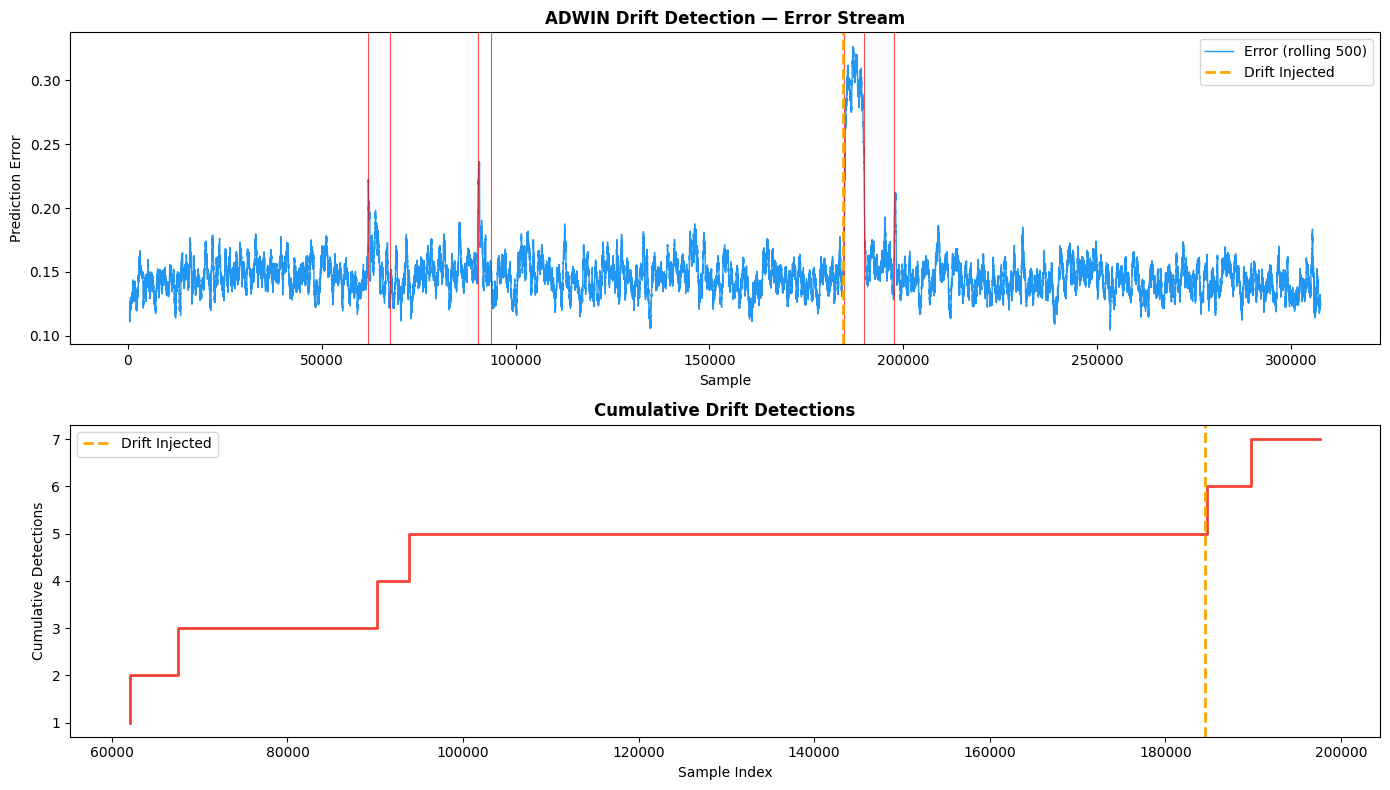

In [19]:
from river import (
    drift as river_drift,
    linear_model as river_lm,
    preprocessing as river_pp,
    metrics as river_metrics,
    ensemble as river_ens,
    tree as river_tree,
    optim,
)
import time

print("🌊 Initialising River online learning pipeline...")

# Build River pipeline: StandardScaler → Hoeffding Adaptive Tree
river_pipeline = river_pp.StandardScaler() | river_tree.HoeffdingAdaptiveTreeClassifier(
    grace_period=200,
    delta=1e-5,
    seed=cfg.SEED,
)

# ADWIN drift detector — detects distribution shifts in the error stream
adwin = river_drift.ADWIN(delta=0.002)

# Track metrics
river_auc      = river_metrics.ROCAUC()
drift_points   = []
retrain_count  = 0
running_errors = []

# Simulate streaming with drift injection
# Use top 30 features for speed
X_stream = X[top30].fillna(0).reset_index(drop=True)
y_stream = y.reset_index(drop=True)

# Inject drift at 60% of the way through
DRIFT_INJECT_AT = int(len(X_stream) * 0.6)
DRIFT_DURATION  = 5000

print(f"🔄 Streaming {len(X_stream):,} samples...")
print(f"   Drift will be injected at sample {DRIFT_INJECT_AT:,}")

start = time.time()

for i, (xi, yi) in enumerate(stream.iter_pandas(X_stream, y_stream)):
    # Inject concept drift
    if DRIFT_INJECT_AT <= i < DRIFT_INJECT_AT + DRIFT_DURATION:
        xi["AMT_INCOME_TOTAL"] = xi.get("AMT_INCOME_TOTAL", 0) * cfg.DRIFT_INCOME_MULTIPLIER
        yi = 1 - yi if np.random.random() < 0.12 else yi  # label noise
    
    # Predict → update metric → learn
    y_prob = river_pipeline.predict_proba_one(xi)
    p1     = y_prob.get(1, 0.5)
    river_auc.update(yi, p1)
    
    error = abs(yi - p1)
    running_errors.append(error)
    adwin.update(error)
    
    if adwin.drift_detected:
        drift_points.append(i)
        retrain_count += 1
        # Reset learner on drift (warm-start)
        river_pipeline = river_pp.StandardScaler() | river_tree.HoeffdingAdaptiveTreeClassifier(
            grace_period=50,  # faster adaptation post-drift
            delta=1e-5,
            seed=cfg.SEED,
        )
        if retrain_count <= 5:
            print(f"  🚨 DRIFT DETECTED at sample {i:,} | Retrain #{retrain_count} | Running AUC: {river_auc.get():.4f}")
    
    river_pipeline.learn_one(xi, yi)

elapsed = time.time() - start
print(f"\n✅ Online learning complete in {elapsed:.1f}s")
print(f"   Final AUC: {river_auc.get():.5f}")
print(f"   Total drift detections: {len(drift_points)}")
print(f"   Total retrains: {retrain_count}")

# Plot error stream + drift points
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

window = 500
smoothed = pd.Series(running_errors).rolling(window).mean()
ax1.plot(smoothed, color="#2196F3", linewidth=1, label=f"Error (rolling {window})")
for dp in drift_points:
    ax1.axvline(dp, color="red", linewidth=0.8, alpha=0.7)
ax1.axvline(DRIFT_INJECT_AT, color="orange", linewidth=2, linestyle="--", label="Drift Injected")
ax1.set_title("ADWIN Drift Detection — Error Stream", fontweight="bold")
ax1.set_xlabel("Sample")
ax1.set_ylabel("Prediction Error")
ax1.legend()

# Cumulative drift detections
ax2.step(drift_points, range(1, len(drift_points)+1), color="#F44336", linewidth=2)
ax2.axvline(DRIFT_INJECT_AT, color="orange", linewidth=2, linestyle="--", label="Drift Injected")
ax2.set_title("Cumulative Drift Detections", fontweight="bold")
ax2.set_xlabel("Sample Index")
ax2.set_ylabel("Cumulative Detections")
ax2.legend()

plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/river_drift_detection.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
import pickle, joblib

# Save LightGBM models
for i, model in enumerate(lgbm_models_final):
    model.save_model(f"{cfg.MODEL_DIR}/lgbm_fold_{i+1}.txt")

# Save XGBoost models
for i, model in enumerate(xgb_models_final):
    model.save_model(f"{cfg.MODEL_DIR}/xgb_fold_{i+1}.json")

# Save PCA + config
joblib.dump(pca, f"{cfg.MODEL_DIR}/pca.pkl")
joblib.dump(scaler_drift, f"{cfg.MODEL_DIR}/scaler.pkl")

# Save feature list
with open(f"{cfg.MODEL_DIR}/feature_cols.json", "w") as f:
    json.dump(FEATURE_COLS, f)

print(f"✅ Models saved to {cfg.MODEL_DIR}")

# Generate submission
submission = pd.DataFrame({
    "SK_ID_CURR": test["SK_ID_CURR"],
    "TARGET":     test_blend
})
submission.to_csv(f"{cfg.OUTPUT_DIR}/submission_ensemble.csv", index=False)
print(f"✅ Submission saved: {submission.shape}")
print(submission.head())

# W&B — final summary run
run = wandb.init(project=cfg.WANDB_PROJECT, name="final-summary", tags=["summary"])
wandb.log({
    "lgbm_baseline_auc":   lgbm_auc,
    "lgbm_optuna_best":    study_lgbm.best_value,
    "xgb_optuna_best":     study_xgb.best_value,
    "ensemble_oof_auc":    roc_auc_score(y, oof_blend),
    "drift_detections":    len(drift_points),
    "total_features":      len(FEATURE_COLS),
    "nlp_features":        cfg.NLP_DIM_REDUCTION,
})
wandb.save(f"{cfg.OUTPUT_DIR}/submission_ensemble.csv")
run.finish()
print("✅ All done. W&B summary logged.")

✅ Models saved to /kaggle/working/models
✅ Submission saved: (48744, 2)
   SK_ID_CURR    TARGET
0      100001  0.035657
1      100005  0.130696
2      100013  0.026649
3      100028  0.039660
4      100038  0.137203


wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


drift_detections,▁
ensemble_oof_auc,▁
lgbm_baseline_auc,▁
lgbm_optuna_best,▁
nlp_features,▁
total_features,▁
xgb_optuna_best,▁
drift_detections,7
ensemble_oof_auc,0.78731
lgbm_baseline_auc,0.77992
lgbm_optuna_best,0.78515


✅ All done. W&B summary logged.
